# 04: Activations, Gradients & BatchNorm — 学習ノートブック

Karpathy「Neural Networks: Zero to Hero」第3回  
**テーマ**: NN の「内部状態」を診断して学習を安定させる

## この章で学ぶ4つのテーマ

| ステップ | 問題 | 解決策 |
|---------|------|--------|
| 1 | **ホッケースティック**: 初期 loss が異常に高い | `W2 *= 0.01` |
| 2 | **tanh 飽和**: ニューロンが死んで学習しない | Kaiming 初期化 |
| 3 | **勾配の可視化**: 消失・爆発を数字で確認する | 1+2 で改善を確認 |
| 4 | **学習中の分布ズレ**: 初期化だけでは限界 | Batch Normalization |

## セットアップ（前回と同じ）

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline

words = open('../data/names.txt', 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)  # 27

block_size = 3

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

random.seed(42)
random.shuffle(words)
n1, n2 = int(0.8 * len(words)), int(0.9 * len(words))
Xtr, Ytr   = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])

n_embd  = 10
n_hidden = 200

print(f'語彙サイズ: {vocab_size}')
print(f'訓練データ: {Xtr.shape}')

語彙サイズ: 27
訓練データ: torch.Size([182625, 3])


---
## STEP 1: ホッケースティック問題

### 理想的な初期 loss はいくつ？

学習前のモデルは「どの文字が来るか全くわからない」状態。  
→ 27文字を均等確率（1/27）で予測するのが理想的。  

$$\text{loss} = -\log(1/27) \approx 3.296$$

### 何が問題？

ランダム初期化のまま `W2` が大きいと：

1. `logits = h @ W2 + b2` の値がバラバラ
2. ある1文字に極端に高い確率が偏る
3. それが不正解だと **巨大な loss**
4. 学習の最初の数千ステップを「loss を正常値に戻す」だけで消費

→ グラフが「急降下してから緩やか」= **ホッケースティック形**

### 修正

`logits ≈ 0` なら `softmax` は均等確率になる。  
→ `W2` を 0.01 倍に縮めれば OK。

In [2]:
g = torch.Generator().manual_seed(2147483647)

C  = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.zeros(n_hidden)

# ミニバッチ（以降も使い回す）
ix = torch.randint(0, Xtr.shape[0], (32,))
Xb, Yb = Xtr[ix], Ytr[ix]
emb = C[Xb]
embcat = emb.view(emb.shape[0], -1)
h = torch.tanh(embcat @ W1 + b1)

ideal_loss = -torch.log(torch.tensor(1.0 / vocab_size)).item()
print(f'理想的な初期 loss: {ideal_loss:.4f}')

# ❌ 悪い初期化
W2_bad = torch.randn((n_hidden, vocab_size), generator=g)
b2_bad = torch.randn(vocab_size, generator=g)
loss_bad = F.cross_entropy(h @ W2_bad + b2_bad, Yb)
print(f'❌ 悪い初期化 loss: {loss_bad.item():.4f}  (理想値より {loss_bad.item()-ideal_loss:.2f} 高い)')

# ✅ 良い初期化
W2_good = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2_good = torch.zeros(vocab_size)
loss_good = F.cross_entropy(h @ W2_good + b2_good, Yb)
print(f'✅ 良い初期化 loss: {loss_good.item():.4f}  (理想値に近い!)')

理想的な初期 loss: 3.2958
❌ 悪い初期化 loss: 23.6058  (理想値より 20.31 高い)
✅ 良い初期化 loss: 3.2766  (理想値に近い!)


---
## STEP 2: tanh 飽和を「目で見る」

### tanh の性質

```
  tanh の傾き（勾配）
     ↑
   1 |   ___________
     |  /           \
   0 |_/             \_____
    -5  -2    0    2   5  → 入力値
```

- **入力 |x| > 2 以上** → 出力が ±1 に張り付く（飽和）
- **飽和すると**: `tanh'(x) ≈ 0` → 勾配 ≈ 0 → 学習しない
- これを **Dead Neuron（死んだニューロン）** と呼ぶ

### 診断方法

`hpreact`（tanh に入る前の値）のヒストグラムを見る。  
- 良い状態: 概ね **-2 〜 +2** の範囲に収まっている  
- 悪い状態: -5 〜 +5 など広範囲 → 大半が飽和ゾーン

/tmp/ipykernel_1783243/3557356941.py:41: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1783243/3557356941.py:41: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1783243/3557356941.py:41: UserWarning: Glyph 24195 (\N{CJK UNIFIED IDEOGRAPH-5E83}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1783243/3557356941.py:41: UserWarning: Glyph 12364 (\N{HIRAGANA LETTER GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1783243/3557356941.py:41: UserWarning: Glyph 12426 (\N{HIRAGANA LETTER RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1783243/3557356941.py:41: UserWarning: Glyph 12377 (\N{HIRAGANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1783243/3557356941.py:41: UserWarning: Glyph 12366 (\N{HIRAGANA LETTER GI}) missing from font(s) Deja

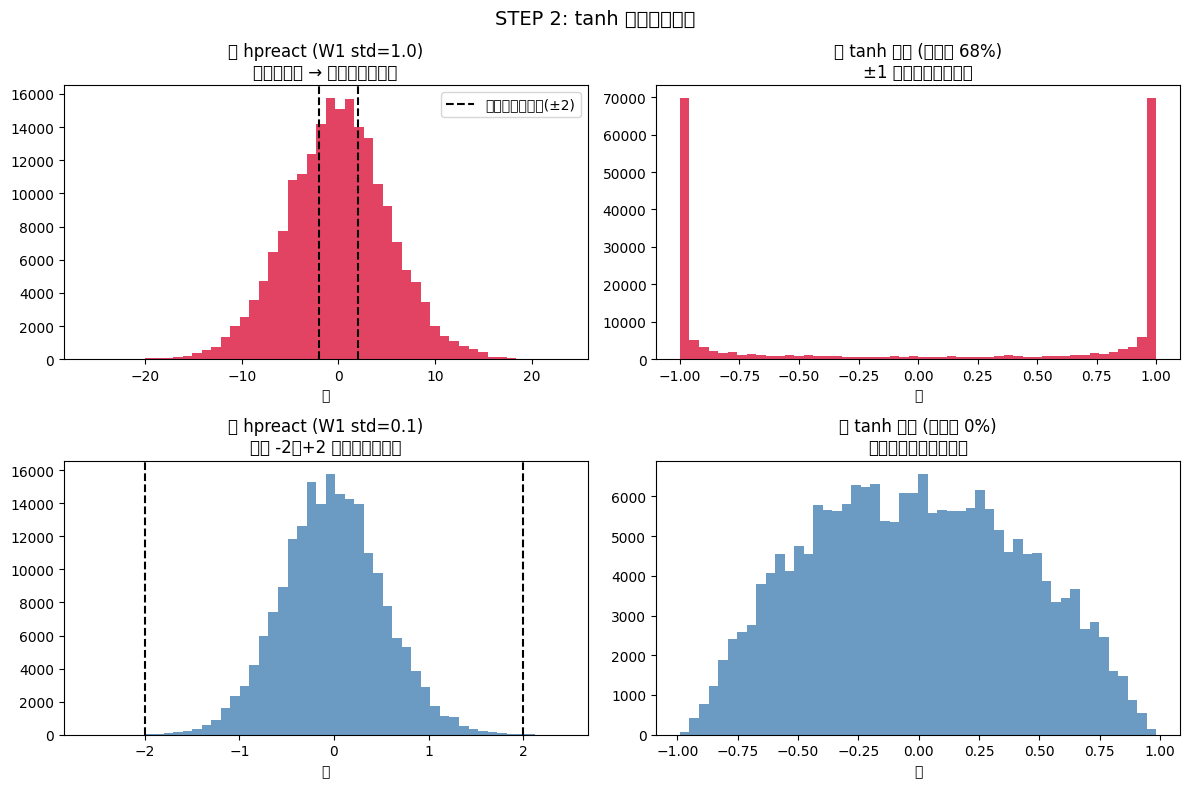

❌ W1 std=1.0 の飽和率: 67.6%
✅ W1 std=0.1 の飽和率: 0.0%


In [3]:
ix_large = torch.randint(0, Xtr.shape[0], (1000,))
emb_large = C[Xtr[ix_large]]
embcat_large = emb_large.view(emb_large.shape[0], -1)

# ❌ W1 スケール大 (std=1.0): 飽和する
W1_big   = torch.randn((n_embd * block_size, n_hidden)) * 1.0
hpre_big = embcat_large @ W1_big
h_big    = torch.tanh(hpre_big)

# ✅ W1 スケール小 (std=0.1): 飽和しない
W1_small   = torch.randn((n_embd * block_size, n_hidden)) * 0.1
hpre_small = embcat_large @ W1_small
h_small    = torch.tanh(hpre_small)

sat_big   = (h_big.abs() > 0.97).float().mean().item()
sat_small = (h_small.abs() > 0.97).float().mean().item()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('STEP 2: tanh 飽和の可視化', fontsize=14)

axes[0, 0].hist(hpre_big.view(-1).detach().numpy(), bins=50, color='crimson', alpha=0.8)
axes[0, 0].axvline(-2, color='k', linestyle='--', label='飽和ゾーン境界(±2)')
axes[0, 0].axvline( 2, color='k', linestyle='--')
axes[0, 0].set_title(f'❌ hpreact (W1 std=1.0)\n広がりすぎ → 飽和ゾーン多数')
axes[0, 0].legend()

axes[0, 1].hist(h_big.view(-1).detach().numpy(), bins=50, color='crimson', alpha=0.8)
axes[0, 1].set_title(f'❌ tanh 出力 (飽和率 {sat_big*100:.0f}%)\n±1 に張り付いている')

axes[1, 0].hist(hpre_small.view(-1).detach().numpy(), bins=50, color='steelblue', alpha=0.8)
axes[1, 0].axvline(-2, color='k', linestyle='--')
axes[1, 0].axvline( 2, color='k', linestyle='--')
axes[1, 0].set_title(f'✅ hpreact (W1 std=0.1)\nほぼ -2〜+2 に収まっている')

axes[1, 1].hist(h_small.view(-1).detach().numpy(), bins=50, color='steelblue', alpha=0.8)
axes[1, 1].set_title(f'✅ tanh 出力 (飽和率 {sat_small*100:.0f}%)\n中間値に広がっている')

for ax in axes.flat:
    ax.set_xlabel('値')

plt.tight_layout()
plt.show()
print(f'❌ W1 std=1.0 の飽和率: {sat_big*100:.1f}%')
print(f'✅ W1 std=0.1 の飽和率: {sat_small*100:.1f}%')

---
## STEP 3: Kaiming 初期化（He の初期化）

### 目標: W1 のスケールを「数学的に正しい値」にする

**直感的な説明:**

n 個の入力を持つ層では `W * x` の分散 = `n × Var(W) × Var(x)`  
→「層を通しても分散が変わらない」には `Var(W) = 1/n`  
→ `std(W) = 1 / sqrt(n)`

**tanh の補正:**

tanh は入力を圧縮するため分散が小さくなる。  
これを補正するため `gain = 5/3` を掛ける（経験則）。

$$\text{Kaiming std} = \frac{5/3}{\sqrt{\text{fan\_in}}}$$

- `fan_in` = 入力ニューロン数 = `n_embd × block_size` = `10 × 3` = 30
- PyTorch では `torch.nn.init.kaiming_normal_()` が自動でやってくれる

fan_in:       30
gain:         1.6667  (tanh 用は 5/3 が経験則)
Kaiming std:  0.3043
  比較: naive=1.0, 小さい=0.1, Kaiming=0.3043


/tmp/ipykernel_1783243/2712449942.py:28: UserWarning: Glyph 39165 (\N{CJK UNIFIED IDEOGRAPH-98FD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1783243/2712449942.py:28: UserWarning: Glyph 21644 (\N{CJK UNIFIED IDEOGRAPH-548C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1783243/2712449942.py:28: UserWarning: Glyph 12478 (\N{KATAKANA LETTER ZO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1783243/2712449942.py:28: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1783243/2712449942.py:28: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1783243/2712449942.py:28: UserWarning: Glyph 22659 (\N{CJK UNIFIED IDEOGRAPH-5883}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1783243/2712449942.py:28: UserWarning: Glyph 30028 (\N{CJK UNIFIED

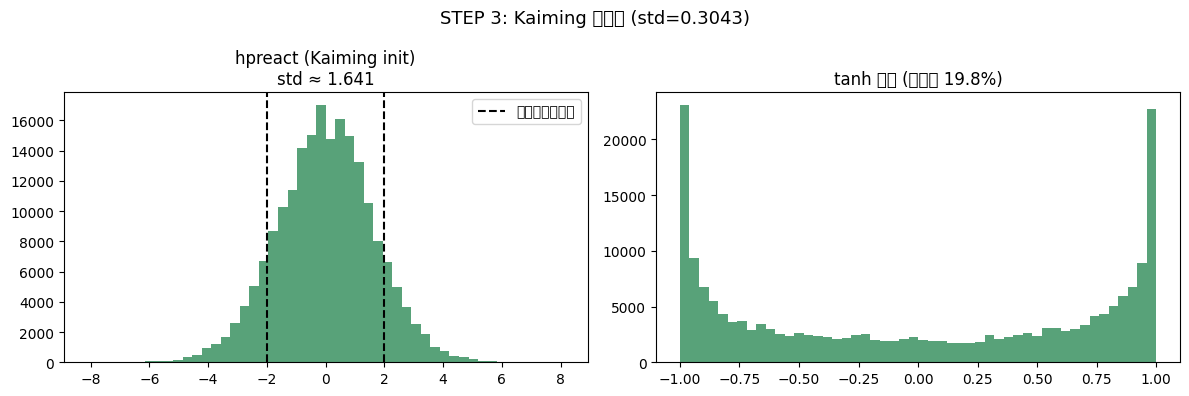


hpreact の標準偏差: 1.6415  (理想: ≈ 1.0)
飽和率: 19.8%


In [4]:
fan_in = n_embd * block_size  # 30
gain   = 5 / 3                 # tanh 用ゲイン（経験則）
kaiming_std = gain / (fan_in ** 0.5)

print(f'fan_in:       {fan_in}')
print(f'gain:         {gain:.4f}  (tanh 用は 5/3 が経験則)')
print(f'Kaiming std:  {kaiming_std:.4f}')
print(f'  比較: naive=1.0, 小さい=0.1, Kaiming={kaiming_std:.4f}')

W1_kaiming   = torch.randn((n_embd * block_size, n_hidden)) * kaiming_std
hpre_kaiming = embcat_large @ W1_kaiming
h_kaiming    = torch.tanh(hpre_kaiming)

sat_kaiming = (h_kaiming.abs() > 0.97).float().mean().item()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'STEP 3: Kaiming 初期化 (std={kaiming_std:.4f})', fontsize=13)

axes[0].hist(hpre_kaiming.view(-1).detach().numpy(), bins=50, color='seagreen', alpha=0.8)
axes[0].axvline(-2, color='k', linestyle='--', label='飽和ゾーン境界')
axes[0].axvline( 2, color='k', linestyle='--')
axes[0].set_title(f'hpreact (Kaiming init)\nstd ≈ {hpre_kaiming.std():.3f}')
axes[0].legend()

axes[1].hist(h_kaiming.view(-1).detach().numpy(), bins=50, color='seagreen', alpha=0.8)
axes[1].set_title(f'tanh 出力 (飽和率 {sat_kaiming*100:.1f}%)')

plt.tight_layout()
plt.show()

print(f'\nhpreact の標準偏差: {hpre_kaiming.std().item():.4f}  (理想: ≈ 1.0)')
print(f'飽和率: {sat_kaiming*100:.1f}%')

---
## STEP 4: 勾配を「見る」

`backward()` の後に `p.grad` を確認することで、学習が健全かどうかを診断できる。

| 状態 | grad の絶対値平均 | 意味 |
|------|-----------------|------|
| 健全 | `1e-3 〜 1e-1` | 正常に学習している |
| 勾配消失 | `≈ 0` | 逆伝播が届いていない |
| 勾配爆発 | `>> 1` | 学習が発散する |

全層でオーダーが揃っているか、ばらついていないかも重要。

名前    | grad 平均(絶対値)       | grad 標準偏差      | 診断
--------------------------------------------------------------
C     | 0.000853           | 0.001460       | ✅ 正常
W1    | 0.000750           | 0.001039       | ✅ 正常
b1    | 0.001189           | 0.001483       | ✅ 正常
W2    | 0.019139           | 0.028934       | ✅ 正常
b2    | 0.038499           | 0.060054       | ✅ 正常


/tmp/ipykernel_1783243/632077002.py:31: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1783243/632077002.py:31: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1783243/632077002.py:31: UserWarning: Glyph 12497 (\N{KATAKANA LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1783243/632077002.py:31: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1783243/632077002.py:31: UserWarning: Glyph 12513 (\N{KATAKANA LETTER ME}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1783243/632077002.py:31: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1783243/632077002.py:31: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) miss

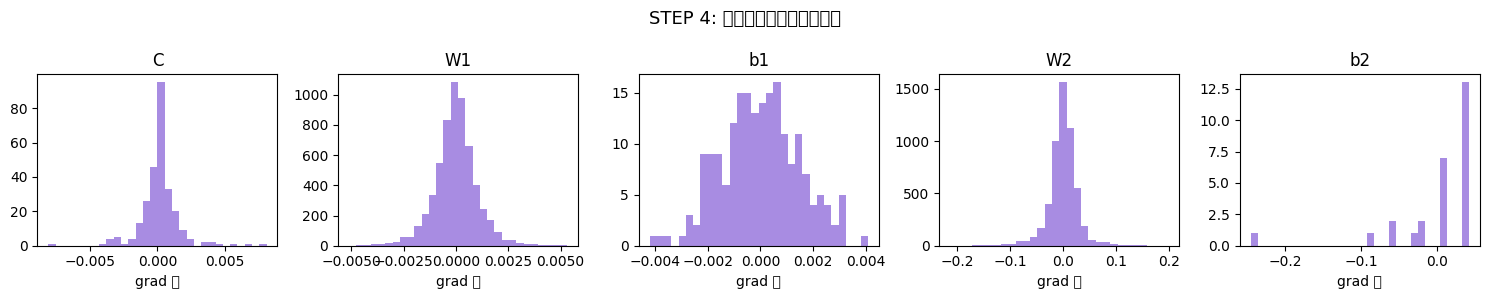

In [5]:
g2 = torch.Generator().manual_seed(2147483647)
C2  = torch.randn((vocab_size, n_embd), generator=g2, requires_grad=True)
W12 = (torch.randn((n_embd * block_size, n_hidden), generator=g2) * kaiming_std).requires_grad_(True)
b12 = torch.zeros(n_hidden, requires_grad=True)
W22 = (torch.randn((n_hidden, vocab_size), generator=g2) * 0.01).requires_grad_(True)
b22 = torch.zeros(vocab_size, requires_grad=True)

params_named = [('C', C2), ('W1', W12), ('b1', b12), ('W2', W22), ('b2', b22)]

emb2    = C2[Xb]
embcat2 = emb2.view(emb2.shape[0], -1)
h2      = torch.tanh(embcat2 @ W12 + b12)
loss2   = F.cross_entropy(h2 @ W22 + b22, Yb)
loss2.backward()

print(f"{'名前':<5} | {'grad 平均(絶対値)':<18} | {'grad 標準偏差':<14} | 診断")
print('-' * 62)
for name, p in params_named:
    gm = p.grad.abs().mean().item()
    gs = p.grad.std().item()
    diag = '⚠ 消失' if gm < 1e-5 else ('⚠ 爆発' if gm > 1.0 else '✅ 正常')
    print(f'{name:<5} | {gm:<18.6f} | {gs:<14.6f} | {diag}')

# 勾配のヒストグラム
fig, axes = plt.subplots(1, len(params_named), figsize=(15, 3))
for ax, (name, p) in zip(axes, params_named):
    ax.hist(p.grad.view(-1).detach().numpy(), bins=30, color='mediumpurple', alpha=0.8)
    ax.set_title(name)
    ax.set_xlabel('grad 値')
fig.suptitle('STEP 4: 各パラメータの勾配分布', fontsize=13)
plt.tight_layout()
plt.show()

---
## STEP 5: Batch Normalization（バッチ正規化）

### 問題

Kaiming 初期化は「学習の最初」だけ安定させる。  
学習が進むにつれ、内部の分布はまたズレていく。

### BatchNorm の発想

「hpreact を毎回強制的に **mean=0, std=1** に正規化してしまえばいい」

```python
# バッチ方向（行方向）で平均・分散を計算
bnmean = hpreact.mean(0, keepdim=True)  # shape: (1, n_hidden)
bnstd  = hpreact.std(0, keepdim=True)
hpreact_norm = (hpreact - bnmean) / (bnstd + 1e-5)
```

### gamma（スケール）と beta（シフト）の役割

正規化しすぎると tanh の中心付近しか使えず表現力が落ちる。  
→ `gamma` と `beta` は「必要なら正規化を緩める」学習可能パラメータ。  
→ 初期値: `gamma=1, beta=0`（まず完全正規化からスタート）

### 推論時の注意

バッチが1サンプルだと mean/std が計算できない。  
→ 学習中に**移動平均**を記録しておき、推論時はそれを使う。

In [ ]:
# BatchNorm の挙動を小さい例で確認
hpre_demo = torch.randn(32, 10) * 5 + 3  # 意図的に mean=3, std=5 に
print(f'正規化前: mean={hpre_demo.mean():.3f}, std={hpre_demo.std():.3f}')

bn_mean = hpre_demo.mean(0, keepdim=True)   # shape: (1, 10)
bn_std  = hpre_demo.std(0, keepdim=True)    # shape: (1, 10)
hpre_normed = (hpre_demo - bn_mean) / (bn_std + 1e-5)
print(f'正規化後: mean={hpre_normed.mean():.3f}, std={hpre_normed.std():.3f}')

bngain = torch.ones((1, 10))   # gamma: スケール（初期=1）
bnbias = torch.zeros((1, 10))  # beta:  シフト（初期=0）
hpre_bn = bngain * hpre_normed + bnbias
print(f'gamma/beta 適用後: mean={hpre_bn.mean():.3f}, std={hpre_bn.std():.3f}')
print('→ 初期値では正規化そのまま。学習が進むと gamma/beta が調整される。')

# 可視化
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(hpre_demo.view(-1).detach().numpy(), bins=30, color='tomato', alpha=0.8)
axes[0].set_title(f'正規化前 (mean≈3, std≈5)')
axes[1].hist(hpre_normed.view(-1).detach().numpy(), bins=30, color='dodgerblue', alpha=0.8)
axes[1].set_title(f'正規化後 (mean≈0, std≈1)')
fig.suptitle('STEP 5: Batch Normalization の効果', fontsize=13)
plt.tight_layout()
plt.show()

---
## STEP 6: 全改善を組み合わせた最終トレーニング

- **W2 × 0.01**: 初期 loss を理想値付近にスタート
- **Kaiming 初期化**: tanh 飽和を防ぐ
- **Batch Normalization**: 学習中も分布を安定させる
- **学習率スケジュール**: 後半に 0.1 → 0.01 に下げてファインチューニング

In [ ]:
g3 = torch.Generator().manual_seed(2147483647)

C3  = torch.randn((vocab_size, n_embd), generator=g3)
W13 = torch.randn((n_embd * block_size, n_hidden), generator=g3) * kaiming_std
b13 = torch.zeros(n_hidden)
W23 = torch.randn((n_hidden, vocab_size), generator=g3) * 0.01
b23 = torch.zeros(vocab_size)

# BatchNorm パラメータ
bngain3 = torch.ones((1, n_hidden))
bnbias3 = torch.zeros((1, n_hidden))

# 推論時に使う移動平均
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running  = torch.ones((1, n_hidden))

parameters3 = [C3, W13, b13, W23, b23, bngain3, bnbias3]
for p in parameters3:
    p.requires_grad_(True)

print(f'総パラメータ数: {sum(p.nelement() for p in parameters3):,}')

In [ ]:
max_steps  = 10000
batch_size = 32
lossi = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g3)
    Xb3, Yb3 = Xtr[ix], Ytr[ix]

    # 順伝播
    emb3     = C3[Xb3]
    embcat3  = emb3.view(emb3.shape[0], -1)
    hpreact3 = embcat3 @ W13 + b13

    # Batch Normalization（学習時）
    bnmean_i = hpreact3.mean(0, keepdim=True)
    bnstd_i  = hpreact3.std(0, keepdim=True)
    hpreact3 = bngain3 * (hpreact3 - bnmean_i) / (bnstd_i + 1e-5) + bnbias3

    # 移動平均を更新（推論時に使う）
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmean_i
        bnstd_running  = 0.999 * bnstd_running  + 0.001 * bnstd_i

    h3      = torch.tanh(hpreact3)
    logits3 = h3 @ W23 + b23
    loss3   = F.cross_entropy(logits3, Yb3)

    # 逆伝播
    for p in parameters3:
        p.grad = None
    loss3.backward()

    # 更新（後半で学習率を下げる）
    lr = 0.1 if i < 5000 else 0.01
    for p in parameters3:
        p.data -= lr * p.grad

    lossi.append(loss3.log10().item())
    if i % 2000 == 0:
        print(f'step {i:6d}/{max_steps}: loss {loss3.item():.4f}')

# 損失グラフ
plt.figure(figsize=(10, 4))
plt.plot(torch.tensor(lossi).view(-1, 100).mean(1).numpy())
plt.xlabel('ステップ (×100)')
plt.ylabel('log10(loss)')
plt.title('学習曲線（BatchNorm + Kaiming + W2小初期化）')
plt.grid(True)
plt.show()

In [ ]:
@torch.no_grad()
def evaluate(X, Y):
    emb     = C3[X]
    embcat  = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W13 + b13
    # 推論時: 移動平均で正規化
    hpreact = bngain3 * (hpreact - bnmean_running) / (bnstd_running + 1e-5) + bnbias3
    h = torch.tanh(hpreact)
    return F.cross_entropy(h @ W23 + b23, Y).item()

print(f'訓練ロス: {evaluate(Xtr, Ytr):.4f}')
print(f'検証ロス: {evaluate(Xdev, Ydev):.4f}')

---
## まとめ

| 問題 | 原因 | 解決策 |
|------|------|--------|
| ホッケースティック | W2 が大きすぎ | `W2 *= 0.01` |
| tanh 飽和 | W1 が大きすぎ | Kaiming 初期化 |
| 勾配消失 | 上2つの組み合わせ | 上記2つで改善 |
| 学習中の分布ズレ | 初期化だけでは限界 | Batch Normalization |

### Batch Normalization が解決するもの

- 初期化が悪くても内部分布を毎回リセット
- 深いネットワークでも安定して学習できる
- 学習率を大きめにできる（= 学習が速い）

### 次のステップ（05_makemore_backprop）

- BatchNorm のような演算を **手動でバックプロパゲーション** する
- PyTorch の自動微分が「何を計算しているか」を自力で再現する